Tested with:
- Python 3.13.9
- numpy 2.4.4
- pandas 2.3.3
- scikit-learn 1.7.2
- rdkit 2026.3.1
- modAL 0.4.2.1
- schnetpack 2.2.0
- ase 3.26.0
- torch 2.6.0+cu124
- torch_geometric 2.7.0
- scikit-activeml 1.0.0
- skorch 1.3.1

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import os
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import sklearn
import skorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import joblib
import skactiveml
import logging
logging.getLogger('skorch').setLevel(logging.WARNING)

from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func
from skactiveml.pool import RandomSampling
from rdkit import Chem
from sklearn.base import clone
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, Subset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SchNet
from torch.optim import Adam
from skorch import NeuralNetRegressor
from skorch.helper import predefined_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from collections import OrderedDict

plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Set seed for reproducibility

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
def seed_set(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_set(42)
torch.use_deterministic_algorithms(True)
generator = torch.Generator().manual_seed(42)

# --- Skorch wrapper ---
class InferenceDataset(Dataset):
    '''
    Returns:
      X = PyG Data object
      y = scalar target tensor
    '''

    def __init__(self, base_dataset, target_idx):
        self.base_dataset = base_dataset
        self.target_idx = target_idx

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        data = self.base_dataset[idx]

        # QM9 targets are often shaped [1, num_targets] per sample.
        y = data.y.view(-1, data.y.shape[-1])[0, self.target_idx].float()

        return data, y

class SchNetRegressorModule(nn.Module):
    def __init__(
        self,
        hidden_channels=128,
        num_filters=128,
        num_interactions=6,
        num_gaussians=50,
        cutoff=10.0,
    ):
        super().__init__()
        self.schnet = SchNet(
            hidden_channels=hidden_channels,
            num_filters=num_filters,
            num_interactions=num_interactions,
            num_gaussians=num_gaussians,
            cutoff=cutoff,
            readout='add',
        )

    def forward(self, data):
        # data is a PyG Batch object from torch_geometric.loader.DataLoader
        out = self.schnet(
            z=data.z,
            pos=data.pos,
            batch=data.batch,
        )

        # Make output shape [batch]
        return out.view(-1)
        
# --- Training and Evaluation Functions for pure PyTorch ---
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
target_idx = 4 # 'gap' in list ['mu', 'alpha', 'homo', 'lumo', 'gap', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv']

def train(loader, model):
    '''
    Train the model for one epoch on loader.

    Optimizes using MSE loss, and reports RMSE, MAE, and MSE
    
    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns: 
        tuple: `(rmse, mae, mse, r2)` for the epoch, or
        `(nan, nan, nan, nan)` if no valid samples are processed.
    '''
    model.train()
    total_loss = total_mae = total_samples = 0
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        if torch.isnan(true).any() or torch.isinf(true).any():
            continue
        
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            continue
        
        optimizer.zero_grad()
        mse_loss = F.mse_loss(pred, true)
        mae_loss = F.l1_loss(pred, true)
        mse_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += mse_loss.item() * data.num_graphs
        total_mae += mae_loss.item() * data.num_graphs
        total_samples += data.num_graphs
        
        y_pred.append(pred.detach().cpu())
        y_true.append(true.detach().cpu())
    y_pred = torch.cat(y_pred).numpy()
    y_true = torch.cat(y_true).numpy()
    
    if total_samples == 0:
        return float('nan'), float('nan'), float('nan'), float('nan')
    
    rmse = np.sqrt(total_loss/total_samples)
    mae = total_mae/total_samples
    mse = total_loss/total_samples
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2

@torch.no_grad()
def evaluate(loader, model):
    '''
    Evaluate model on loader and compute regression metrics.

    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns:
        tuple: `(rmse, mae, mse, r2, y_true, y_pred)`, where `y_true` and
        `y_pred` are NumPy arrays containing the true and predicted values.
    '''
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        y_pred.append(pred.cpu().numpy())
        y_true.append(true.cpu().numpy())
    y_pred = np.concatenate(y_pred)
    y_true = np.concatenate(y_true)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2, y_true, y_pred

@torch.no_grad()
def plot_prediction(dataset, model, model_name=None, name='gap', figsize=(6, 6), save=None, format='pdf', skorch=True):
    '''
    Plot predicted vs. true values for model on loader.

    Computes evaluation metrics, displays a scatter plot of true versus
    predicted values with a reference diagonal, and prints MAE, MSE, RMSE,
    and R^2.

    Args:
        dataset: PyTorch Dataset (pt compatible dataset).
        model: Fitted model (torch compatible model).
        model_name: Name of the model (str).
        name: Name of the target value (str). 
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    if skorch:
        y_true = np.array([dataset[i].y.view(-1)[target_idx].item() for i in range(len(dataset))]).flatten()*27.2114
        y_pred = model.predict(InferenceDataset(dataset, target_idx=target_idx)).flatten()*27.2114
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = root_mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
    else:
        loader = DataLoader(dataset)
        rmse, mae, mse, r2, y_true, y_pred = evaluate(loader, model)
        y_true *= 27.2114
        y_pred *= 27.2114
    
    errors = np.abs(y_true - y_pred)/y_true
    norm = colors.Normalize(vmin=0.0, vmax=1.0, clip=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y_true, y_pred, c=errors, cmap='viridis', norm=norm, label='predicted values')
    ax.plot(y_true, y_true, 'r-', label='ideal')
    ax.set_xlabel(f'true {name}', fontsize=14)
    ax.set_ylabel(f'predicted {name}', fontsize=14)
    ax.legend(facecolor='white', fontsize=14)
    if model_name is None:
        ax.set_title(f'{model.__class__.__name__} prediction plot\n{name}', fontsize=16)
    else:
        ax.set_title(f'{model_name} prediction plot\n{name}', fontsize=16)
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mae:.4f}')
    print(f'MSE = {mse:.4f}') 
    print(f'RMSE = {rmse:.4f}')
    print(f'r^2 = {r2:.4f}')

In [18]:
# Draw 3D structure of a molecule
import py3Dmol
from ase import Atoms
from ase.io import write
from io import StringIO


def show_ase_atoms_3d(atoms, width=500, height=400):
    buf = StringIO()
    write(buf, atoms, format='xyz')
    xyz = buf.getvalue()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, 'xyz')
    view.setStyle(
        {
            'stick': {'radius': 0.15},
            'sphere': {'scale': 0.28},
        }
    )
    view.zoomTo()
    return view.show()

dataset = torch.load('../data/qm9/qm9.pt', weights_only=False)
entry = dataset[4809]
atoms = Atoms(numbers=entry.z, positions=entry.pos)
show_ase_atoms_3d(atoms)
print(f'gap = {entry.y[4]:.4f} Ha')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

gap = 0.2199 Ha


### Load dataset

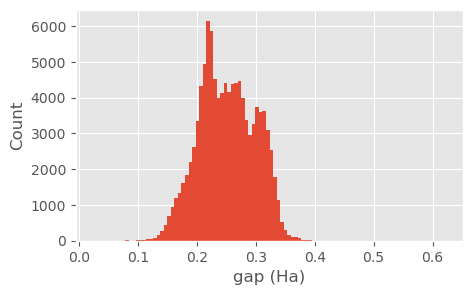

Min gap: 0.0246 Ha
Max gap: 0.6221 Ha


In [46]:
# Plot train histogram
train_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in train_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(train_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {train_gaps.min():.4f} Ha')
print(f'Max gap: {train_gaps.max():.4f} Ha')

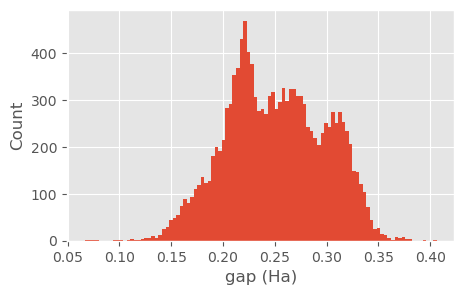

Min gap: 0.0663 Ha
Max gap: 0.4063 Ha


In [47]:
# Plot test histogram
test_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in test_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(test_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {test_gaps.min():.4f} Ha')
print(f'Max gap: {test_gaps.max():.4f} Ha')

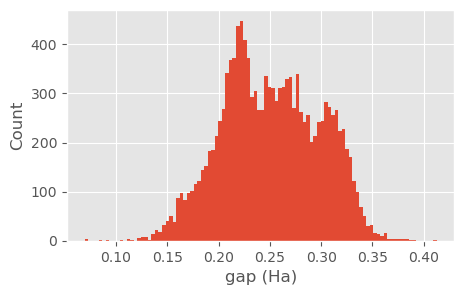

Min gap: 0.0692 Ha
Max gap: 0.4128 Ha


In [48]:
# Plot val histogram
val_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in val_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(val_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {val_gaps.min():.4f} Ha')
print(f'Max gap: {val_gaps.max():.4f} Ha')

In [2]:
# --- DataLoaders ---
train_dataset = torch.load('../data/qm9/gap/qm9_gap_train.pt', weights_only=False)
test_dataset = torch.load('../data/qm9/gap/qm9_gap_test.pt', weights_only=False)
val_dataset = torch.load('../data/qm9/gap/qm9_gap_val.pt', weights_only=False)

# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=generator)
# test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
# val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [14]:
print(train_dataset[0].z)

tensor([6, 6, 6, 6, 6, 6, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [2]:
# --- DataLoaders(Sample) ---
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset

train_dataset = torch.load('../data/qm9/gap/qm9_gap_train.pt', weights_only=False)
test_dataset = torch.load('../data/qm9/gap/qm9_gap_test.pt', weights_only=False)
val_dataset = torch.load('../data/qm9/gap/qm9_gap_val.pt', weights_only=False)

sample_ratio = 0.1
rng = np.random.default_rng(42)

train_n = max(1, int(len(train_dataset) * sample_ratio))
val_n = max(1, int(len(val_dataset) * sample_ratio))
test_n = max(1, int(len(test_dataset) * sample_ratio))

train_idx = rng.choice(len(train_dataset), size=train_n, replace=False)
val_idx = rng.choice(len(val_dataset), size=val_n, replace=False)
test_idx = rng.choice(len(test_dataset), size=test_n, replace=False)

train_dataset = [train_dataset[i] for i in train_idx]
val_dataset = [val_dataset[i] for i in val_idx]
test_dataset = [test_dataset[i] for i in test_idx]

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=generator)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Baseline

## Schnet

### Training

#### PyTorch

In [5]:
from torch_geometric.nn import SchNet
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Create a config dictionary
config = {
    'hidden_channels': 64,
    'num_filters': 256,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 6.0,
    'target_idx': 4, # 'gap'
    'readout' : 'add',
}

# Define model
model = SchNet(
    hidden_channels=config['hidden_channels'],
    num_filters=config['num_filters'],
    num_interactions=config['num_interactions'],
    num_gaussians=config['num_gaussians'],
    cutoff=config['cutoff'],
    readout=config['readout'],
).to(device)

# Define optimizer
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Training Loop
epochs=500
counter=0
early_stopping=10

best_rmse = float('inf')
history = {'train_rmse': [], 'train_mae': [], 'train_mse': [], 'test_rmse': [], 'test_mae': [], 'test_mse': [], 'test_r2': []}

epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch', ncols=150)
for epoch in epoch_bar:
    train_rmse, train_mae, train_mse, train_r2 = train(train_loader, model)
    test_rmse, test_mae, test_mse, test_r2, test_y_true, test_y_pred  = evaluate(test_loader, model)
    
    scheduler.step(test_mse)

    # Track history
    history['train_rmse'].append(train_rmse)
    history['train_mae'].append(train_mae)
    history['train_mse'].append(train_mse)
    history['test_rmse'].append(test_rmse)
    history['test_mae'].append(test_mae)
    history['test_mse'].append(test_mse)
    history['test_r2'].append(test_r2)

    # Save best model
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        counter=0
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config
        }, 'models/schnet/schnet_gap_qm9_2.pt')
    else:
        counter+=1

    epoch_bar.set_postfix(
        train_rmse=f'{train_rmse:.4f}',
        test_rmse=f'{test_rmse:.4f}',
        best_rmse=f'{best_rmse:.4f}',
        lr=f'{optimizer.param_groups[0]['lr']:.1e}',
        paitence_counter=f'{counter}/{early_stopping}'
    )
    
    if counter >= early_stopping:
            print('Early stopping triggered.')
            break    
print(f'Best test RMSE: {best_rmse:.4f}')

df = pd.DataFrame(history)
df.to_csv('models/schnet/history_schnet_gap_qm9_2.csv', index=False)

Training: 100%|████| 500/500 [33:02:19<00:00, 237.88s/epoch, best_rmse=0.0059, lr=1.0e-06, paitence_counter=9/20, test_rmse=0.0060, train_rmse=0.0052]

Best test RMSE: 0.0059


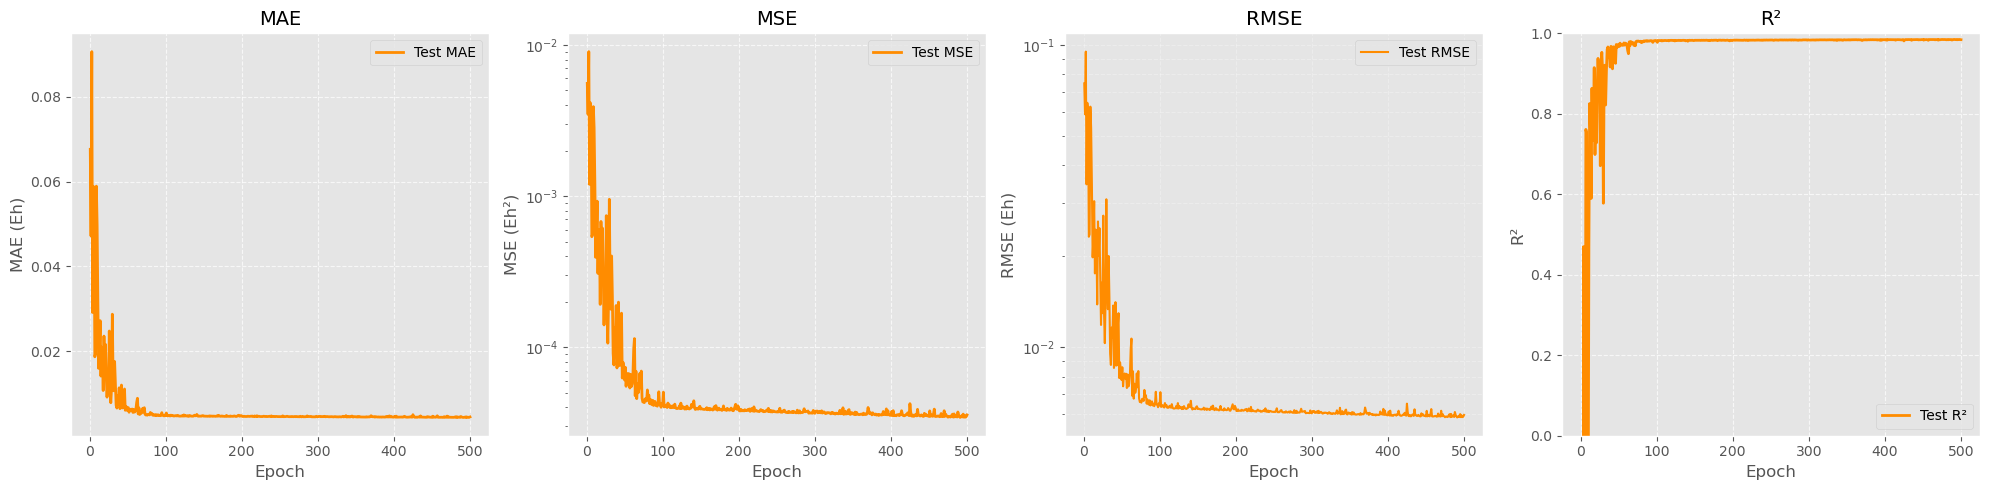

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, save=None, format='pdf'):
    epochs = range(1, len(history['train_mae']) + 1)
    
    # Create a figure with two side-by-side plots
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

    # --- Plot 1: MAE (Mean Absolute Error) ---
    ax1.plot(epochs, history['test_mae'], label='Test MAE', color='darkorange', lw=2)
    ax1.set_title('MAE', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('MAE (Eh)', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: MSE (Mean Squared Error) ---
    ax2.semilogy(epochs, history['test_mse'], label='Test MSE', color='darkorange', lw=2)
    ax2.set_title('MSE', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('MSE (Eh²)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 3: RMSE (Log Scale) ---
    ax3.semilogy(epochs, history['test_rmse'], label='Test RMSE', color='darkorange')
    ax3.set_title('RMSE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('RMSE (Eh)')
    ax3.legend()
    ax3.grid(True, which='both', linestyle='--', alpha=0.3)

    # --- Plot 4: R2 ---
    ax4.plot(epochs, history['test_r2'], label='Test R²', color='darkorange', lw=2)
    ax4.set_title('R²', fontsize=14)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('R²', fontsize=12)
    ax4.set_ylim(0, 1)
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.7)


    plt.tight_layout()
    if save is not None:
        plt.savefig(save, format=format, dpi=300)
    plt.show()

df = pd.read_csv('models/schnet/history_schnet_gap_qm9_2.csv')
history = df.to_dict(orient='list')
plot_history(history, save='models/schnet/history_schnet_gap_qm9_2.png', format='png')

#### Skorch

In [ ]:
model = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=256,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,
    criterion=nn.MSELoss,
    optimizer=torch.optim.Adam,
    lr=1e-4,
    batch_size=32,
    max_epochs=100,
    iterator_train=DataLoader,
    iterator_valid=DataLoader,
    iterator_train__shuffle=True,
    iterator_train__num_workers=0,
    iterator_valid__num_workers=0,
    train_split=predefined_split(InferenceDataset(test_dataset, target_idx=target_idx)), # Pre-defined test split for validation during training
    device=device,
    verbose=1,  # Turn off standard epoch output prints from skorch
    callbacks=[
        ('lr_scheduler', LRScheduler(
            policy=ReduceLROnPlateau,
            monitor='valid_loss',  # Tracks validation MSE loss
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )),
        ('early_stopping', EarlyStopping(
            monitor='valid_loss',
            patience=10,
            lower_is_better=True,
            threshold=0.001,
            threshold_mode='rel',
        )),
        ('checkpoint', Checkpoint(
            f_params='models/schnet/skorch/skorch_schnet_gap_qm9_1.pt',
            f_history='models/schnet/skorch/history_skorch_schnet_gap_qm9_1.json',
            f_criterion=None,
            f_optimizer=None,
            monitor='valid_loss_best',
            load_best=True,
        )),
    ],
)

model.fit(InferenceDataset(train_dataset, target_idx=target_idx), y=None)

### Model evaluation

#### PyTorch
- schnet_gap_qm9_sample.pt: optimizer = Adam, start learning rate = 1e-3, epochs = 100 (diverged)
- schnet_gap_qm9_0.pt: optimizer = Adam, start learning rate = 1e-3, epochs = 100 (diverged)
- schnet_gap_qm9_1.pt: optimizer = Adam, start learning rate = 1e-3, epochs = 100 (diverged)
- schnet_gap_qm9_2.pt: optimizer = Adam, start learning rate = __1e-4__, epochs = 500 (converged)

In [15]:
#Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load('models/schnet/pyg/schnet_gap_qm9_2.pt', map_location=device)
conf = checkpoint['config']

# Automatically use the saved hyperparameters
model = SchNet(
    hidden_channels=conf['hidden_channels'],
    num_filters=conf['num_filters'],
    num_interactions=conf['num_interactions'],
    num_gaussians=conf['num_gaussians'],
    cutoff=conf['cutoff'],
    readout=conf.get('readout', 'add'),
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

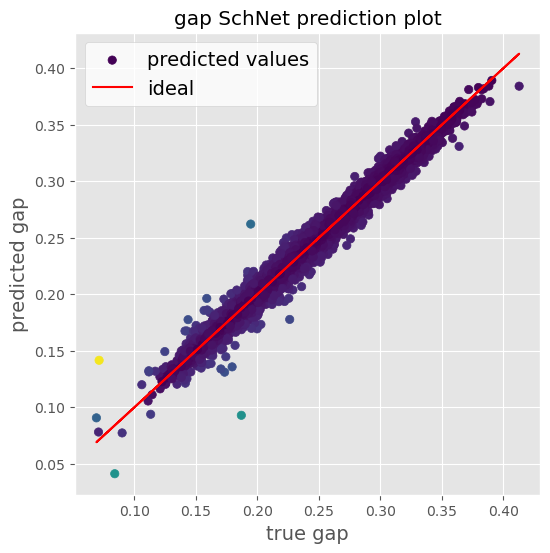

Training scores:
MAE = 0.0043
MSE = 0.0000
RMSE = 0.0059
r^2 = 0.9848


In [16]:
plot_prediction(val_dataset, model, save=None)

#### Skorch
- skorch_schnet_gap_qm9_0.pt: optimizer = Adam, start learning rate = 1e-4, epochs = 100 (diverged, something wrong with dataset wrapper)
- skorch_schnet_gap_qm9_1.pt: optimizer = Adam, start learning rate = 1e-4, epochs = 100 (converged, new dataset wrapper used)

In [53]:
#Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=256,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,
    device=device,
    iterator_valid=DataLoader,
    batch_size=32,
)

model.initialize()
model.load_params(f_params='models/schnet/skorch/skorch_schnet_gap_qm9_1.pt')

#Load w/o skorch wrapping
# checkpoint = torch.load('models/schnet/skorch/skorch_schnet_gap_qm9_1.pt', map_location=device)
# new_checkpoint = OrderedDict()
# for k, v in checkpoint.items():
#     if k.startswith('schnet.'):
#         new_checkpoint[k[len('schnet.'):]] = v
#     else:
#         new_checkpoint[k] = v
        
# conf = {
#     'hidden_channels': 64,
#     'num_filters': 256,
#     'num_interactions': 6,
#     'num_gaussians': 50,
#     'cutoff': 6.0,
#     'target_idx': 4, # 'gap'
#     'readout' : 'add',
# }

# Automatically use the saved hyperparameters
# model = SchNet(
#     hidden_channels=conf['hidden_channels'],
#     num_filters=conf['num_filters'],
#     num_interactions=conf['num_interactions'],
#     num_gaussians=conf['num_gaussians'],
#     cutoff=conf['cutoff'],
#     readout=conf.get('readout', 'add'),
# ).to(device)

# model.load_state_dict(new_checkpoint)

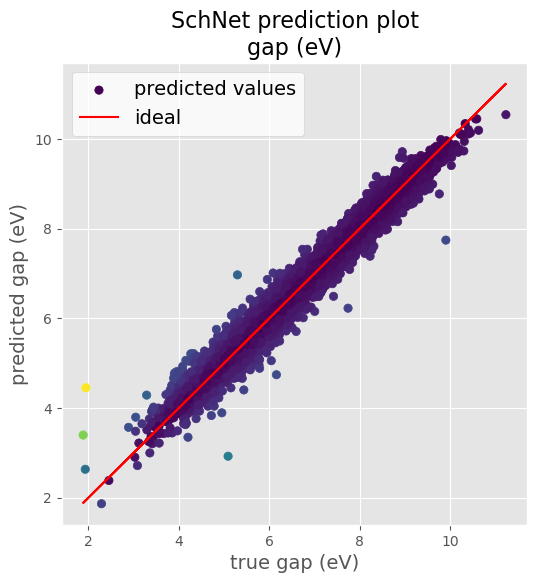

Training scores:
MAE = 0.1565
MSE = 0.0434
RMSE = 0.2082
r^2 = 0.9740


In [52]:
plot_prediction(val_dataset, model, model_name='SchNet', name='gap (eV)', save='models/schnet/skorch/plot_skorch_schnet_gap_qm9_1.png', format='png')

# AL Query Strategies

In [3]:
def al_loop_rnd_skorch(
    skorch_model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run an Active Learning loop with physical neural networks using skorch wrappers
    and skactiveml's native Query Strategies.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)
    
    X_train_indices = np.arange(len(train_dataset)).reshape(-1, 1)
    
    # X_train = InferenceDataset(train_dataset, target_idx=target_idx)
    X_val = InferenceDataset(val_dataset, target_idx=target_idx)
    X_test = InferenceDataset(test_dataset, target_idx=target_idx)

    y_val_true = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()
    y_test_true = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()
    y_train_all = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
    
    all_histories = []

    for run in range(n_runs):
        run_seed = int(run_seeds[run])
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'=' * 60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'=' * 60}')

        # ── Label pool initialization ─────────────────────────────────────────
        y_pool = np.full(len(train_dataset), MISSING_LABEL)
        initial_idx = run_rng.choice(len(train_dataset), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train_all[initial_idx]

        # ── Query strategy ────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)

        # Clear PyTorch caching and create a clean clone of the wrapped model
        torch.cuda.empty_cache()
        reg = clone(skorch_model)

        if n_cycles is None:
            n_cycles = math.ceil((len(train_dataset) - n_initial) / batch_size) + 1

        # ── Active-learning loop ──────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_idx)

            X_train_subset = InferenceDataset(torch.utils.data.Subset(train_dataset, labeled_idx), target_idx=target_idx)

            # 1. Train model utilizing skorch fit mechanics
            reg.fit(X_train_subset, y=None)

            # 2. Record predictions
            y_pred_test = reg.predict(X_test).flatten()
            y_pred_val = reg.predict(X_val).flatten()

            mae_test = mean_absolute_error(y_test_true, y_pred_test)
            mse_test = mean_squared_error(y_test_true, y_pred_test)
            rmse_test = root_mean_squared_error(y_test_true, y_pred_test)
            r2_test = r2_score(y_test_true, y_pred_test)

            mae_val = mean_absolute_error(y_val_true, y_pred_val)
            mse_val = mean_squared_error(y_val_true, y_pred_val)
            rmse_val = root_mean_squared_error(y_val_true, y_pred_val)
            r2_val = r2_score(y_val_true, y_pred_val)

            row = {
                'run':        run + 1,
                'cycle':      cycle + 1,
                'n_labeled':  n_labeled,
                'mae_test':   mae_test,
                'mse_test':   mse_test,
                'rmse_test':  rmse_test,
                'r2_test':    r2_test,
                'mae_val':    mae_val,
                'mse_val':    mse_val,
                'rmse_val':   rmse_val,
                'r2_val':     r2_val,
                'queried_idx': initial_idx.tolist() if cycle == 0 else query_idx.tolist(),
            }

            all_histories.append(row)
            if save is not None:
                pd.DataFrame(all_histories).to_csv(save, index=False)
                
            print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
            
            if len(unlabeled_idx) == 0:                
                print('All pool samples labeled.')
                break

            # 3. Query new samples using the skactiveml framework
            query_idx = rnd.query(
                X=X_train_indices,
                y=y_pool,
                batch_size=batch_size,
            )
            
            y_pool[query_idx] = y_train_all[query_idx]

        print(f'\nDone. Final labeled count: {len(labeled_indices(y_pool))}/{len(train_dataset)}')
        df = pd.DataFrame(all_histories)
        if save is not None:
            df.to_csv(save, index=False)
    return df

In [3]:
model = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=256,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,
    criterion=nn.MSELoss,
    optimizer=torch.optim.Adam,
    lr=1e-4,
    batch_size=32,
    max_epochs=100,
    iterator_train=DataLoader,
    iterator_valid=DataLoader,
    iterator_train__shuffle=True,
    iterator_train__num_workers=0,
    iterator_valid__num_workers=0,
    train_split=predefined_split(InferenceDataset(test_dataset, target_idx=target_idx)), # Pre-defined test split for validation during training
    device=device,
    verbose=1,  # Turn off standard epoch output prints from skorch
    callbacks=[
        ('lr_scheduler', LRScheduler(
            policy=ReduceLROnPlateau,
            monitor='valid_loss',  # Tracks validation MSE loss
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )),
        ('early_stopping', EarlyStopping(
            monitor='valid_loss',
            patience=10,
            lower_is_better=True,
            threshold=0.001,
            threshold_mode='rel',
        )),
        ('checkpoint', Checkpoint(
            f_params=None,
            f_history=None,
            f_criterion=None,
            f_optimizer=None,
            monitor='valid_loss_best',
            load_best=True,
        )),
    ],
)

In [ ]:
results = al_loop_rnd_skorch(skorch_model=model, n_runs=1, save='active_learning/schnet/qm9/al_history_schnet_gap_qm9.csv')


Run 1/1  (seed=191664964)


In [66]:
def df_groupby(df):
    '''
    Regroups the AL history df into a new df for plotting.

    Args:
        df : AL history df (pd.DataFrame)
    '''
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

def plot_al(dfs, labels, score, save=None, format='pdf'):
    '''
    Plot AL metrics base on labeled samples.

    Args:
        dfs : List of Data Frames modified with df_groupby (list).
        labels : List of AL strategies (list).
        score : Dictionary of metric scores of baseline model (dict).
        save : Save path (str).
        format : Save format (str).
    '''
    metrics = [
        ('mae_test', 'MAE (Eh)'),
        ('rmse_test', 'RMSE (Eh)'),
        ('r2_test', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key],
                marker='o',
                color=color,
                label=name,
                linewidth=3,
            )
            # ax.fill_between(
            #     df['n_labeled'],
            #     df[f'min_{key}'],
            #     df[f'max_{key}'],
            #     alpha=0.2,
            #     color=color,
            # )

        # Plot the baseline reference line
        # baseline_val = score[key]
        # ax.axhline(
        #     baseline_val,
        #     color='black',
        #     ls='--',
        #     label=f'full = {baseline_val:.4f}',
        #     linewidth=2,
        # )

        
        ax.set_title(label, fontsize=16)
        ax.set_xlabel('Labeled samples', fontsize=16)
        ax.set_ylabel(label, fontsize=16)
        ax.legend(facecolor='white', fontsize=14)
        ax.tick_params(axis='both', labelsize=14)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()

In [88]:
rnd_sample = df_groupby(pd.read_csv('active_learning/schnet/qm9/al_history_schnet_gap_qm9.csv'))

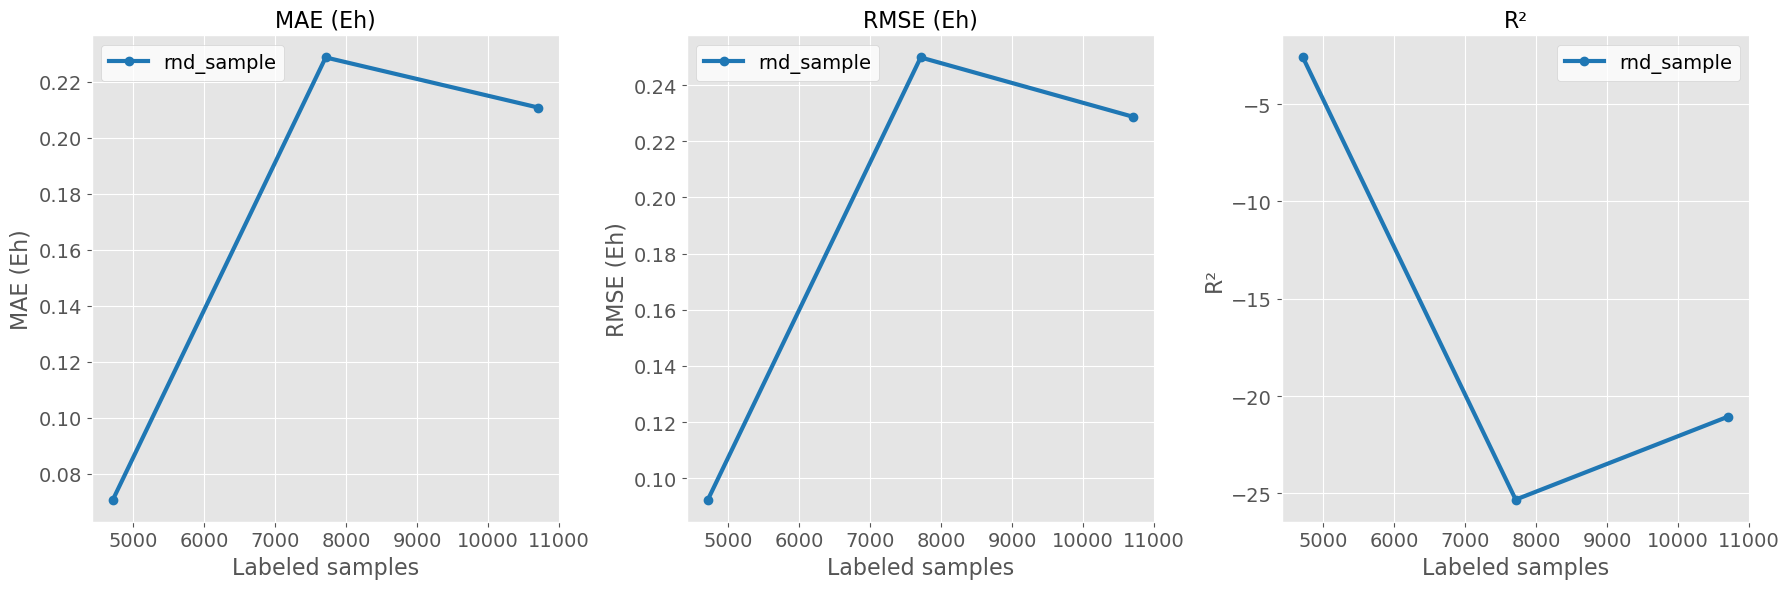

In [89]:
plot_al([rnd_sample], ['rnd_sample'], None)